In [2]:
pip install pandas numpy linearmodels statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from linearmodels.panel import PooledOLS
from linearmodels.panel import PanelOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
data = pd.read_csv("/home/onyxia/work/STATAPP_V2/Notebooks/Import des données/données_caracteristiques_communes.csv")
data.head()

/tmp/ipykernel_19599/3530202150.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/home/onyxia/work/STATAPP_V2/Notebooks/Import des données/données_caracteristiques_communes.csv")


,Unnamed: 0,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,...,pbac,psup,revmoy,vote_EG_pres,abstention_pres,vote_RN_pres,vote_EG_leg,abstention_leg,vote_RN_leg,typologie_urbaine
0,0,1001,1995,662,0.471756,0.268702,0.280916,0.258015,0.192366,0.016320,...,0.117925,0.073113,12110.340,0.076056,0.201285,0.225352,NaN,NaN,NaN,Rural non périurbain
1,1,1001,1996,678,0.468657,0.270149,0.270149,0.265672,0.194030,0.017366,...,0.121560,0.075688,11530.236,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain
2,2,1001,1997,695,0.467930,0.272595,0.259475,0.271137,0.196793,0.016997,...,0.127232,0.080357,12207.807,NaN,NaN,NaN,0.098639,0.337607,0.20068,Rural non périurbain
3,3,1001,1998,711,0.465714,0.272857,0.250000,0.278571,0.198571,0.018006,...,0.132321,0.082429,12892.058,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain
4,4,1001,1999,728,0.463687,0.273743,0.240223,0.284916,0.201117,0.018945,...,0.135593,0.084746,12839.338,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain


In [5]:
data.columns

Index(['Unnamed: 0', 'codecommune', 'Annee', 'pop', 'propf', 'prop014',
       'prop1539', 'prop4059', 'prop60p', 'petranger', 'pcapi', 'pouem',
       'paind', 'pchom', 'pbac', 'psup', 'revmoy', 'vote_EG_pres',
       'abstention_pres', 'vote_RN_pres', 'vote_EG_leg', 'abstention_leg',
       'vote_RN_leg', 'typologie_urbaine'],
      dtype='object')

In [6]:
data["typologie_urbaine"].unique()

array(['Rural non périurbain', 'Urbain intermédiaire', 'Rural périurbain',
       'Urbain dense'], dtype=object)

# Modélisation vote RN Prez

Modèle naïf utilisé : 

$$VoteRN_{it} = \alpha_i + \gamma_t + \sum_{\tau \in \{2012, 2017, 2022\}} \beta_{\tau} (Rural_i \times \mathbb{1}_{t=\tau}) + \epsilon_{it}$$

Modèle avec contrôles : 

$$VoteRN_{it} = \alpha_i + \gamma_t + \sum_{\tau \in \{2012, 2017, 2022\}} \widetilde{\beta}_{\tau} (Rural_i \times \mathbb{1}_{t=\tau}) + \delta X_{it} + \eta_{it}$$

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# 1. Nettoyage et création de la tendance
df_clean = data.dropna(subset=['vote_RN_pres', 'typologie_urbaine', 'Annee', 'codecommune']).copy()
annee_min = df_clean['Annee'].min()
df_clean['tendance'] = df_clean['Annee'] - annee_min

# 2. CRÉATION MANUELLE DES INTERACTIONS (La solution anti-bugs !)
# On laisse "Urbain dense" de côté, c'est notre référence absolue (sa pente sera à 0)
df_clean['tend_urbain_inter'] = (df_clean['typologie_urbaine'] == 'Urbain intermédiaire') * df_clean['tendance']
df_clean['tend_rural_peri'] = (df_clean['typologie_urbaine'] == 'Rural périurbain') * df_clean['tendance']
df_clean['tend_rural_non_peri'] = (df_clean['typologie_urbaine'] == 'Rural non périurbain') * df_clean['tendance']

# 3. Indexation du Panel
df_panel = df_clean.set_index(['codecommune', 'Annee'])

# ---------------------------------------------------------
# ÉTAPE 1 : Modèle de base
# ---------------------------------------------------------
formula_base = 'vote_RN_pres ~ 1 + tend_urbain_inter + tend_rural_peri + tend_rural_non_peri + EntityEffects + TimeEffects'

mod_base = PanelOLS.from_formula(formula_base, data=df_panel, drop_absorbed=True)
res_base = mod_base.fit(cov_type='clustered', cluster_entity=True)
print("=== MODÈLE SANS CONTRÔLES ===")
print(res_base.summary)

=== MODÈLE SANS CONTRÔLES ===
                          PanelOLS Estimation Summary                           
Dep. Variable:           vote_RN_pres   R-squared:                        0.0463
Estimator:                   PanelOLS   R-squared (Between):             -0.0224
No. Observations:              208975   R-squared (Within):               0.5077
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.2846
Time:                        18:02:38   Log-likelihood                 3.694e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2814.9
Entities:                       34852   P-value                           0.0000
Avg Obs:                       5.9961   Distribution:                F(3,174115)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             1200.

In [8]:
# ---------------------------------------------------------
# ÉTAPE 2 : Ajout des variables de contrôle
# ---------------------------------------------------------
df_panel_controls = df_clean.dropna(
    subset=['pbac', 'psup', 'revmoy', 'petranger', 'pchom', 'pouem', 'paind']
).set_index(['codecommune', 'Annee'])

formula_controls = (
    'vote_RN_pres ~ 1 + tend_urbain_inter + tend_rural_peri + tend_rural_non_peri + '
    'pbac + psup + revmoy + petranger + pchom + pouem + paind + '
    'EntityEffects + TimeEffects'
)

mod_controls = PanelOLS.from_formula(formula_controls, data=df_panel_controls, drop_absorbed=True)
res_controls = mod_controls.fit(cov_type='clustered', cluster_entity=True)
print("\n=== MODÈLE AVEC CONTRÔLES ===")
print(res_controls.summary)


=== MODÈLE AVEC CONTRÔLES ===
                          PanelOLS Estimation Summary                           
Dep. Variable:           vote_RN_pres   R-squared:                        0.0626
Estimator:                   PanelOLS   R-squared (Between):             -0.0055
No. Observations:              206016   R-squared (Within):               0.5006
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.2884
Time:                        18:02:42   Log-likelihood                 3.699e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1144.0
Entities:                       34740   P-value                           0.0000
Avg Obs:                       5.9302   Distribution:               F(10,171261)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             468.

# Modélisation vote RN Leg

Modèle naïf utilisé : 

$$VoteRN_{it} = \alpha_i + \gamma_t + \sum_{\tau \in \{2012, 2017, 2022\}} \beta_{\tau} (Rural_i \times \mathbb{1}_{t=\tau}) + \epsilon_{it}$$

Modèle avec contrôles : 

$$VoteRN_{it} = \alpha_i + \gamma_t + \sum_{\tau \in \{2012, 2017, 2022\}} \widetilde{\beta}_{\tau} (Rural_i \times \mathbb{1}_{t=\tau}) + \delta X_{it} + \eta_{it}$$

Pourquoi une approche agrégée ?

Dans l'approche agrégée, tu définis "Urbain dense" comme référence. Le modèle te recrache un coefficient direct (ex: +3 points) pour le "Rural" avec une p-value (sa significativité statistique).

Avantage : Tu prouves mathématiquement que la différence de vote entre la campagne et la ville est statistiquement significative.

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# 1. Nettoyage et création de la tendance
df_clean = data.dropna(subset=['vote_RN_pres', 'typologie_urbaine', 'Annee', 'codecommune']).copy()
annee_min = df_clean['Annee'].min()
df_clean['tendance'] = df_clean['Annee'] - annee_min

# 2. CRÉATION MANUELLE DES INTERACTIONS (La solution anti-bugs !)
# On laisse "Urbain dense" de côté, c'est notre référence absolue (sa pente sera à 0)
df_clean['tend_urbain_inter'] = (df_clean['typologie_urbaine'] == 'Urbain intermédiaire') * df_clean['tendance']
df_clean['tend_rural_peri'] = (df_clean['typologie_urbaine'] == 'Rural périurbain') * df_clean['tendance']
df_clean['tend_rural_non_peri'] = (df_clean['typologie_urbaine'] == 'Rural non périurbain') * df_clean['tendance']

# 3. Indexation du Panel
df_panel = df_clean.set_index(['codecommune', 'Annee'])

# ---------------------------------------------------------
# ÉTAPE 1 : Modèle de base
# ---------------------------------------------------------
formula_base = 'vote_RN_leg ~ 1 + tend_urbain_inter + tend_rural_peri + tend_rural_non_peri + EntityEffects + TimeEffects'

mod_base = PanelOLS.from_formula(formula_base, data=df_panel, drop_absorbed=True)
res_base = mod_base.fit(cov_type='clustered', cluster_entity=True)
print("=== MODÈLE SANS CONTRÔLES ===")
print(res_base.summary)

/opt/python/lib/python3.13/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


=== MODÈLE SANS CONTRÔLES ===
                          PanelOLS Estimation Summary                           
Dep. Variable:            vote_RN_leg   R-squared:                        0.0146
Estimator:                   PanelOLS   R-squared (Between):             -0.0156
No. Observations:              174159   R-squared (Within):               0.3857
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.2388
Time:                        18:02:46   Log-likelihood                 2.951e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      688.30
Entities:                       34852   P-value                           0.0000
Avg Obs:                       4.9971   Distribution:                F(3,139300)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             433.3

In [10]:
# ---------------------------------------------------------
# ÉTAPE 2 : Ajout des variables de contrôle
# ---------------------------------------------------------
df_panel_controls = df_clean.dropna(
    subset=['pbac', 'psup', 'revmoy', 'petranger', 'pchom', 'pouem', 'paind']
).set_index(['codecommune', 'Annee'])

formula_controls = (
    'vote_RN_leg ~ 1 + tend_urbain_inter + tend_rural_peri + tend_rural_non_peri + '
    'pbac + psup + revmoy + petranger + pchom + pouem + paind + '
    'EntityEffects + TimeEffects'
)

mod_controls = PanelOLS.from_formula(formula_controls, data=df_panel_controls, drop_absorbed=True)
res_controls = mod_controls.fit(cov_type='clustered', cluster_entity=True)
print("\n=== MODÈLE AVEC CONTRÔLES ===")
print(res_controls.summary)

/opt/python/lib/python3.13/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)



=== MODÈLE AVEC CONTRÔLES ===
                          PanelOLS Estimation Summary                           
Dep. Variable:            vote_RN_leg   R-squared:                        0.0210
Estimator:                   PanelOLS   R-squared (Between):             -0.0156
No. Observations:              173057   R-squared (Within):               0.3743
Date:                Sun, Apr 19 2026   R-squared (Overall):              0.2315
Time:                        18:02:51   Log-likelihood                 2.951e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      296.72
Entities:                       34740   P-value                           0.0000
Avg Obs:                       4.9815   Distribution:               F(10,138303)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             165.

## Décompositions de Gelbach 

Le problème à résoudre
Nous constatons que l'introduction des variables socio-économiques réduit l'effet géographique brut (par exemple, une baisse de 3 points du coefficient). Toutefois, le modèle global ne permet pas d'isoler le canal d'action exact : cette baisse est-elle due au fait que les populations rurales sont en moyenne moins diplômées ? Qu'elles appartiennent davantage à la catégorie des ouvriers ? Ou qu'elles disposent de revenus plus faibles ?

La décomposition de Gelbach
Cette méthode économétrique permet d'ouvrir la « boîte noire » des variables de contrôle. Elle décompose la différence exacte entre le coefficient naïf et le coefficient contrôlé afin de l'attribuer à chaque variable (ou groupe de variables). Elle permet d'aboutir à des conclusions chiffrées précises, telles que : 
« Sur les 4 points d'écart de vote entre l'espace rural et urbain, 2 points s'expliquent par le canal du diplôme, 0,8 point par la composition socio-professionnelle, et 0,2 point par les écarts de revenus. »

Formalisation mathématique

Formellement, si $\beta_{naif}$ représente l'écart géographique de base et $\beta_{controle}$ cet écart résiduel une fois les contrôles ajoutés, la méthode de Gelbach (2016) démontre la relation suivante :

\begin{equation}
    \beta_{naif} - \beta_{controle} = \sum_{k=1}^{K} \delta_k \Gamma_k
\end{equation}

Où :
$\delta_k$ : correspond à l'effet de la variable socio-économique $k$ sur le vote RN (le coefficient issu du modèle final avec contrôles).

$\Gamma_k$ : représente le lien entre la typologie rurale et cette variable $k$ (il s'agit du coefficient de la variable rurale dans une régression auxiliaire expliquant $k$, captant ainsi la "sur-représentation" de cette caractéristique à la campagne).

DÉCOMPOSITION DE GELBACH — Vote RN Présidentiel

Variable géo                     β_naïf   β_contrôlé     Δ réel
--------------------------------------------------------------
Urbain intermédiaire             0.0028       0.0029    -0.0000
Rural périurbain                 0.0049       0.0048     0.0000
Rural non périurbain             0.0054       0.0053     0.0001

Décomposition de l'écart Δ = β_naïf − β_contrôlé

► Urbain intermédiaire  (Δ réel = -0.0000)
  Canal                       δ_k      Γ_gk   Contribution      % Δ
  --------------------------------------------------------------
  % Bac                    0.0236    0.0002         0.0000   -20.6%
  % Supérieur             -0.0611   -0.0007         0.0000  -220.6%
  Revenu moyen            -0.0000   50.5943        -0.0001   462.7%
  % Étrangers             -0.0205   -0.0009         0.0000  -100.0%
  % Chômage                0.0030   -0.0003        -0.0000     5.5%
  % Ouvriers/Empl.        -0.0022   -0.0005         0.0000    -5.

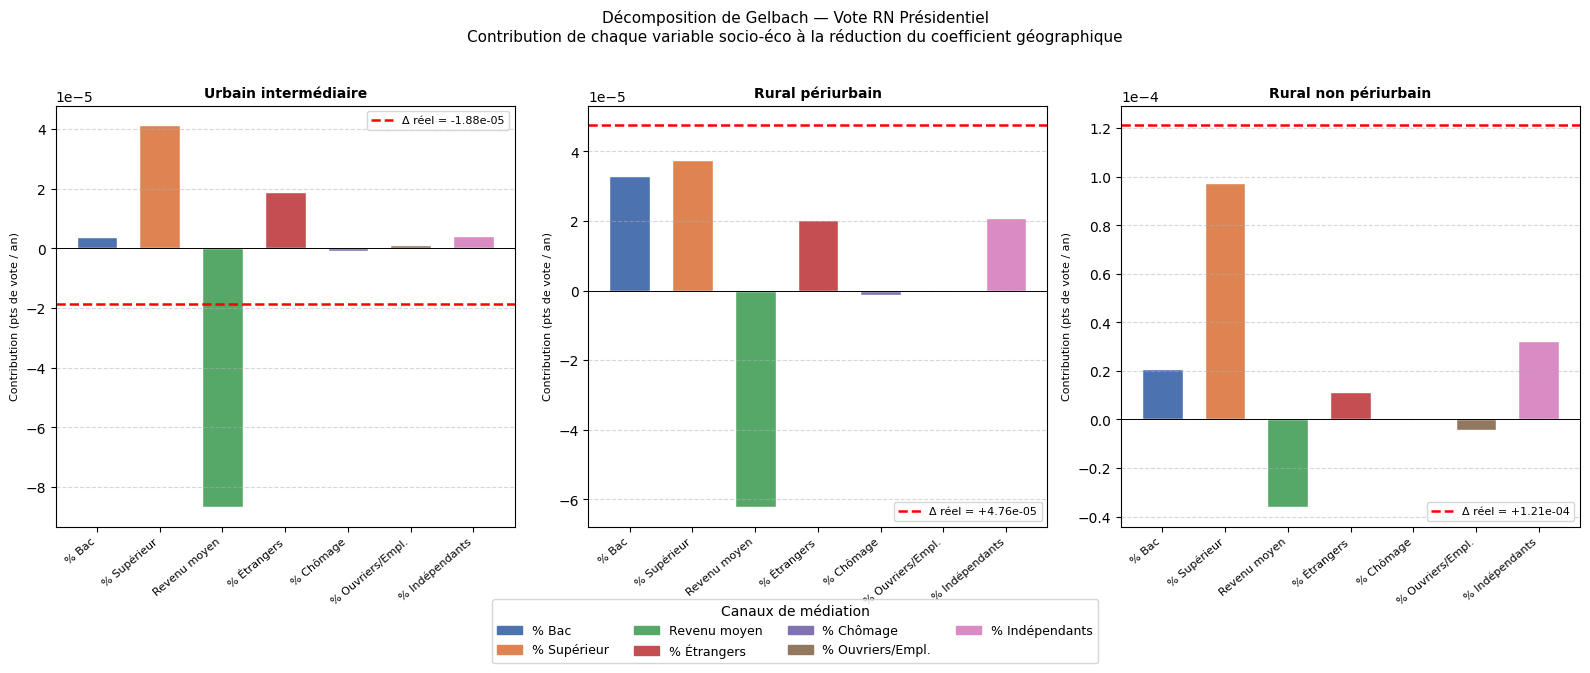

DÉCOMPOSITION DE GELBACH — Vote RN Législatif

Variable géo                     β_naïf   β_contrôlé     Δ réel
--------------------------------------------------------------
Urbain intermédiaire             0.0027       0.0027    -0.0000
Rural périurbain                 0.0042       0.0041     0.0000
Rural non périurbain             0.0043       0.0042     0.0001

Décomposition de l'écart Δ = β_naïf − β_contrôlé

► Urbain intermédiaire  (Δ réel = -0.0000)
  Canal                       δ_k      Γ_gk   Contribution      % Δ
  --------------------------------------------------------------
  % Bac                    0.0220    0.0002         0.0000   -16.3%
  % Supérieur             -0.0497   -0.0006         0.0000   -96.9%
  Revenu moyen            -0.0000   49.3947        -0.0001   235.1%
  % Étrangers             -0.0045   -0.0010         0.0000   -14.0%
  % Chômage                0.0041   -0.0003        -0.0000     4.0%
  % Ouvriers/Empl.        -0.0053   -0.0006         0.0000   -10.0%

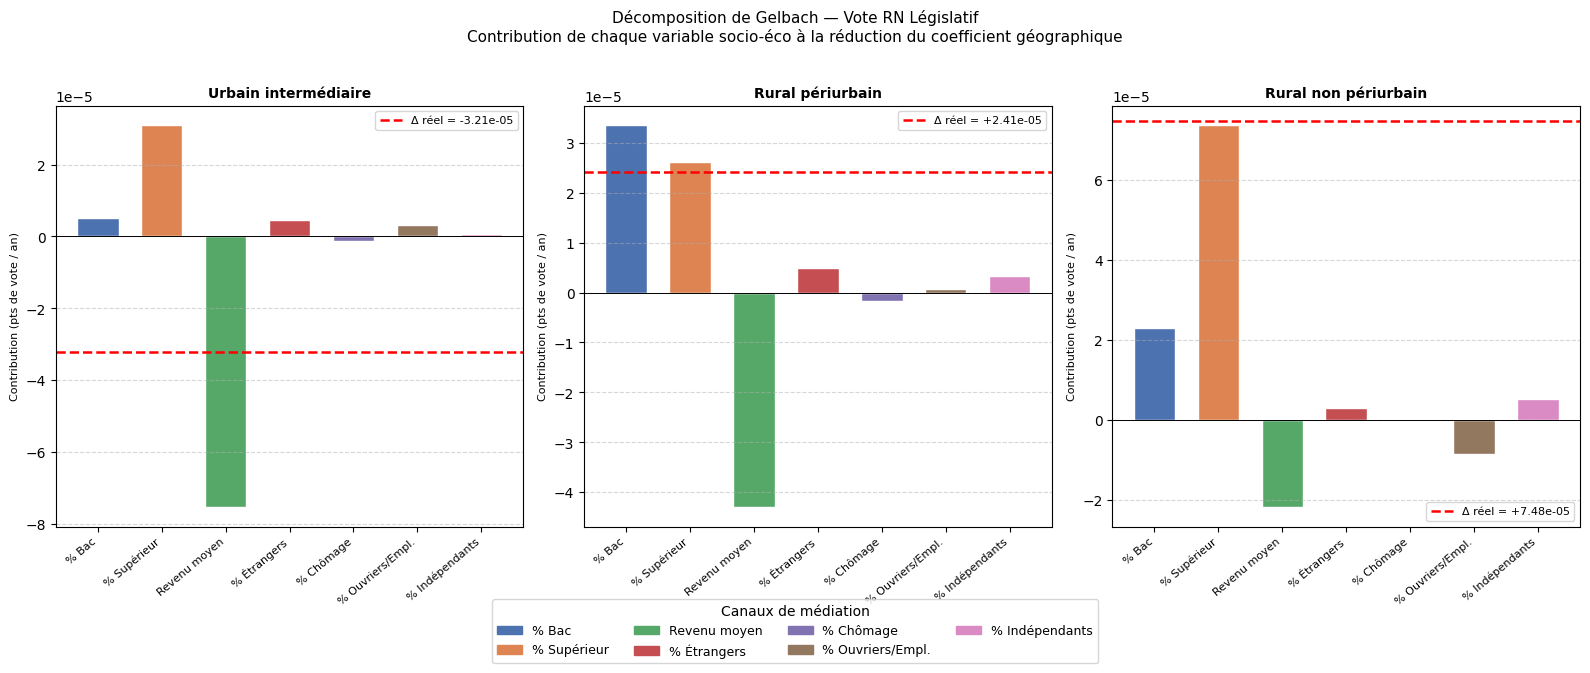

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from linearmodels.panel import PanelOLS

# ============================================================
# DÉCOMPOSITION DE GELBACH — Formalisation
# ============================================================
# Identité exacte : β_naïf - β_contrôlé = Σ_k  δ_k * Γ_gk
#
#   δ_k   = coeff. de la variable socio-éco k dans le modèle COMPLET
#   Γ_gk  = coeff. de la variable géo g dans la régression auxiliaire
#             qui régresse k sur toutes les vars géo + effets fixes
#
# On itère sur les deux votes (présidentiel et législatif).
# ============================================================

CONTROLS = ['pbac', 'psup', 'revmoy', 'petranger', 'pchom', 'pouem', 'paind']
GEO_VARS = ['tend_urbain_inter', 'tend_rural_peri', 'tend_rural_non_peri']

LABELS_GEO = {
    'tend_urbain_inter':   'Urbain intermédiaire',
    'tend_rural_peri':     'Rural périurbain',
    'tend_rural_non_peri': 'Rural non périurbain',
}

LABELS_CONTROLS = {
    'pbac':      '% Bac',
    'psup':      '% Supérieur',
    'revmoy':    'Revenu moyen',
    'petranger': '% Étrangers',
    'pchom':     '% Chômage',
    'pouem':     '% Ouvriers/Empl.',
    'paind':     '% Indépendants',
}

COLORS = {
    'pbac':      '#4C72B0',
    'psup':      '#DD8452',
    'revmoy':    '#55A868',
    'petranger': '#C44E52',
    'pchom':     '#8172B2',
    'pouem':     '#937860',
    'paind':     '#DA8BC3',
}


def gelbach_decomposition(data, dep_var, label):
    """
    Applique la décomposition de Gelbach sur la variable dépendante dep_var.
    Retourne un dict {geo_var: {control: contribution}}.
    """
    # ── Préparation du panel ────────────────────────────────────
    df = data.dropna(
        subset=[dep_var, 'typologie_urbaine', 'Annee', 'codecommune'] + CONTROLS
    ).copy()

    annee_min = df['Annee'].min()
    df['tendance']             = df['Annee'] - annee_min
    df['tend_urbain_inter']    = (df['typologie_urbaine'] == 'Urbain intermédiaire') * df['tendance']
    df['tend_rural_peri']      = (df['typologie_urbaine'] == 'Rural périurbain')      * df['tendance']
    df['tend_rural_non_peri']  = (df['typologie_urbaine'] == 'Rural non périurbain')  * df['tendance']

    panel = df.set_index(['codecommune', 'Annee'])

    # ── Modèle naïf (sans contrôles) ───────────────────────────
    f_naive = (f'{dep_var} ~ 1 + tend_urbain_inter + tend_rural_peri '
               f'+ tend_rural_non_peri + EntityEffects + TimeEffects')
    res_naive = PanelOLS.from_formula(f_naive, data=panel, drop_absorbed=True).fit(
        cov_type='clustered', cluster_entity=True)

    # ── Modèle complet (avec contrôles) ────────────────────────
    ctrl_str = ' + '.join(CONTROLS)
    f_full = (f'{dep_var} ~ 1 + tend_urbain_inter + tend_rural_peri '
              f'+ tend_rural_non_peri + {ctrl_str} + EntityEffects + TimeEffects')
    res_full = PanelOLS.from_formula(f_full, data=panel, drop_absorbed=True).fit(
        cov_type='clustered', cluster_entity=True)

    # ── Régressions auxiliaires ─────────────────────────────────
    # Pour chaque contrôle k : régresser k sur les 3 vars géo + FE
    # On récupère Γ_gk = coeff de la var géo g dans cette régression
    gamma = {}          # gamma[k][geo] = Γ_gk
    for k in CONTROLS:
        f_aux = (f'{k} ~ 1 + tend_urbain_inter + tend_rural_peri '
                 f'+ tend_rural_non_peri + EntityEffects + TimeEffects')
        res_aux = PanelOLS.from_formula(f_aux, data=panel, drop_absorbed=True).fit(
            cov_type='clustered', cluster_entity=True)
        gamma[k] = {g: res_aux.params[g] for g in GEO_VARS}

    # ── Calcul des contributions ────────────────────────────────
    # Contribution de k à la réduction du coeff géo g :
    #   contrib(k, g) = δ_k * Γ_gk
    results = {}
    for g in GEO_VARS:
        results[g] = {}
        for k in CONTROLS:
            delta_k = res_full.params[k]        # effet de k sur vote RN
            gamma_gk = gamma[k][g]              # lien géo → k
            results[g][k] = delta_k * gamma_gk

    # ── Affichage texte ─────────────────────────────────────────
    print("=" * 70)
    print(f"DÉCOMPOSITION DE GELBACH — {label}")
    print("=" * 70)
    print(f"\n{'Variable géo':<30} {'β_naïf':>8} {'β_contrôlé':>12} {'Δ réel':>10}")
    print("-" * 62)
    for g in GEO_VARS:
        bn = res_naive.params[g]
        bf = res_full.params[g]
        print(f"{LABELS_GEO[g]:<30} {bn:>8.4f} {bf:>12.4f} {bn - bf:>10.4f}")

    print("\n" + "=" * 70)
    print("Décomposition de l'écart Δ = β_naïf − β_contrôlé")
    print("=" * 70)

    for g in GEO_VARS:
        beta_naive = res_naive.params[g]
        beta_full  = res_full.params[g]
        delta_real = beta_naive - beta_full

        print(f"\n► {LABELS_GEO[g]}  (Δ réel = {delta_real:+.4f})")
        print(f"  {'Canal':<22} {'δ_k':>8}  {'Γ_gk':>8}  {'Contribution':>13}  {'% Δ':>7}")
        print(f"  {'-'*62}")
        total = 0
        for k in CONTROLS:
            dk   = res_full.params[k]
            ggk  = gamma[k][g]
            cb   = results[g][k]
            pct  = cb / delta_real * 100 if delta_real != 0 else float('nan')
            print(f"  {LABELS_CONTROLS[k]:<22} {dk:>8.4f}  {ggk:>8.4f}  {cb:>13.4f}  {pct:>6.1f}%")
            total += cb
        print(f"  {'─'*62}")
        print(f"  {'TOTAL (vérif.)':<22} {'':>8}  {'':>8}  {total:>13.4f}  {'≈100%':>7}")
        print(f"  {'Δ réel':<22} {'':>8}  {'':>8}  {delta_real:>13.4f}")
        print(f"  → Erreur de vérification : {abs(total - delta_real):.2e}")

    # ── Graphique ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

    for ax, g in zip(axes, GEO_VARS):
        contribs   = results[g]
        vals       = [contribs[k] for k in CONTROLS]
        cols       = [COLORS[k] for k in CONTROLS]
        x_pos      = np.arange(len(CONTROLS))

        bars = ax.bar(x_pos, vals, color=cols, edgecolor='white', width=0.65)

        # Ligne Δ réel (doit coïncider avec la somme des barres)
        delta_real = res_naive.params[g] - res_full.params[g]
        ax.axhline(delta_real, color='red', linewidth=1.8, linestyle='--',
                   label=f'Δ réel = {delta_real:+.2e}')
        ax.axhline(0, color='black', linewidth=0.7)

        ax.set_title(LABELS_GEO[g], fontsize=10, fontweight='bold')
        ax.set_ylabel('Contribution (pts de vote / an)', fontsize=8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([LABELS_CONTROLS[k] for k in CONTROLS],
                           rotation=40, ha='right', fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        # Force la notation scientifique sur l'axe y pour tous les sous-graphes
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    # Légende commune
    patches = [mpatches.Patch(color=COLORS[k], label=LABELS_CONTROLS[k]) for k in CONTROLS]
    fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9,
               title='Canaux de médiation', bbox_to_anchor=(0.5, -0.08))

    plt.suptitle(
        f"Décomposition de Gelbach — {label}\n"
        "Contribution de chaque variable socio-éco à la réduction du coefficient géographique",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

    return results


# ── Application aux deux votes ──────────────────────────────────────
res_gelbach_pres = gelbach_decomposition(data, 'vote_RN_pres', 'Vote RN Présidentiel')
res_gelbach_leg  = gelbach_decomposition(data, 'vote_RN_leg',  'Vote RN Législatif')


# RN Prez part inexpliquée : un modèle par type de territoire

L'approche d'avant (Un seul modèle global) : Tu forçais ton modèle à calculer un seul et unique coefficient pour tes variables de contrôle. Le modèle partait du principe que gagner 1000€ de revenu moyen ou avoir 10% de diplômés du supérieur en plus avait exactement le même impact sur le vote RN en plein centre-ville de Paris que dans un village rural très isolé.

La nouvelle approche (Un modèle par type de territoire) : En séparant ta base de données (la boucle for typo in typologies), tu permets au modèle de calculer des coefficients sur-mesure. Le chômage ou le niveau de diplôme peuvent avoir un effet très fort sur le vote RN dans les zones rurales, mais un effet plus faible dans les zones urbaines. C'est beaucoup plus réaliste sociologiquement.

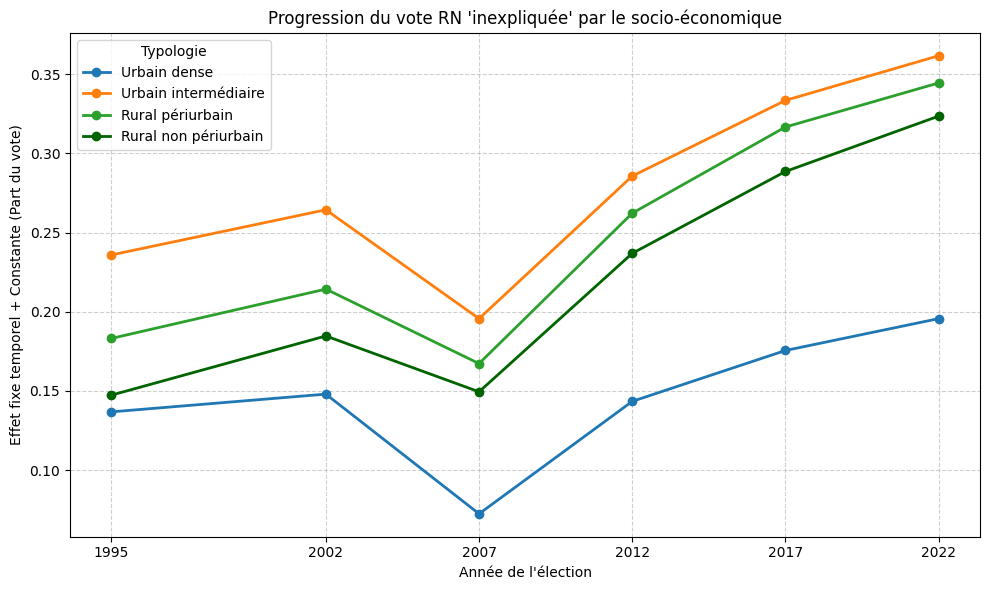

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

# 1. Nettoyage de base
df_clean = data.dropna(subset=['vote_RN_pres', 'typologie_urbaine', 'Annee', 'codecommune']).copy()

# Pour éviter TOUT bug de nom de variable (KeyError), on crée manuellement les dummies d'années.
# 1995 (ou 1992) est notre année de référence, on ne la crée pas.
annees_estimees = [2002, 2007, 2012, 2017, 2022]
for annee in annees_estimees:
    df_clean[f'annee_{annee}'] = (df_clean['Annee'] == annee).astype(int)

# On configure le Panel
df_panel = df_clean.set_index(['codecommune', 'Annee'])

# Les 4 catégories présentes dans ta base
typologies = ['Urbain dense', 'Urbain intermédiaire', 'Rural périurbain', 'Rural non périurbain']

# Dictionnaire pour stocker les résultats pour le graphique
# On met 1995 comme point de départ
resultats_graphique = {'Année': [1995] + annees_estimees}

# 2. Boucle : Une régression par sous-groupe (typologie)
for typo in typologies:
    # On isole uniquement les communes de ce type
    df_sub = df_panel[df_panel['typologie_urbaine'] == typo]
    
    # Formule avec contrôles (car ton titre de graph dit "inexpliquée par le socio-éco")
    # On ajoute nos dummies d'années manuels + les contrôles + Effet Fixe Commune
    # (Tu peux enlever les contrôles si tu veux le modèle naïf)
    formule = (
        'vote_RN_pres ~ 1 + annee_2002 + annee_2007 + annee_2012 + annee_2017 + annee_2022 + '
        'pbac + psup + revmoy + petranger + pchom + pouem + paind + EntityEffects'
    )
    
    # On fait tomber les NaN spécifiques aux contrôles sur ce sous-groupe
    df_sub_clean = df_sub.dropna(subset=['pbac', 'psup', 'revmoy', 'petranger', 'pchom', 'pouem', 'paind'])
    
    mod = PanelOLS.from_formula(formule, data=df_sub_clean, drop_absorbed=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    
    # 3. Extraction pour le graphique
    # L'ordonnée à l'origine (Intercept) nous donne le niveau moyen de base en 1995
    base_1995 = res.params['Intercept']
    
    # On ajoute le coefficient de chaque année à la base de 1995 pour avoir le niveau réel
    trajectoire = [base_1995] # Premier point : 1995
    for annee in annees_estimees:
        niveau_annee = base_1995 + res.params[f'annee_{annee}']
        trajectoire.append(niveau_annee)
        
    # On sauvegarde la trajectoire pour cette typologie
    resultats_graphique[typo] = trajectoire

# 4. Dessin du graphique (style identique à ta capture)
df_plot = pd.DataFrame(resultats_graphique).set_index('Année')

fig, ax = plt.subplots(figsize=(10, 6))

# Couleurs pour différencier urbain/rural (tu peux ajuster)
couleurs = {
    'Urbain dense': '#1f77b4',          # Bleu
    'Urbain intermédiaire': '#ff7f0e',  # Orange
    'Rural périurbain': '#2ca02c',      # Vert clair
    'Rural non périurbain': '#006400'   # Vert foncé
}

# Tracé des lignes
for typo in typologies:
    ax.plot(df_plot.index, df_plot[typo], marker='o', label=typo, color=couleurs[typo], linewidth=2)

# Esthétique
ax.set_title("Progression du vote RN 'inexpliquée' par le socio-économique")
ax.set_ylabel("Effet fixe temporel + Constante (Part du vote)")
ax.set_xlabel("Année de l'élection")
ax.set_xticks(resultats_graphique['Année']) # Force l'affichage de tes années exactes
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Typologie')

plt.tight_layout()
plt.show()

# RN Leg part inexpliquée : un modèle par type de territoire

L'approche d'avant (Un seul modèle global) : Tu forçais ton modèle à calculer un seul et unique coefficient pour tes variables de contrôle. Le modèle partait du principe que gagner 1000€ de revenu moyen ou avoir 10% de diplômés du supérieur en plus avait exactement le même impact sur le vote RN en plein centre-ville de Paris que dans un village rural très isolé.

La nouvelle approche (Un modèle par type de territoire) : En séparant ta base de données (la boucle for typo in typologies), tu permets au modèle de calculer des coefficients sur-mesure. Le chômage ou le niveau de diplôme peuvent avoir un effet très fort sur le vote RN dans les zones rurales, mais un effet plus faible dans les zones urbaines. C'est beaucoup plus réaliste sociologiquement.

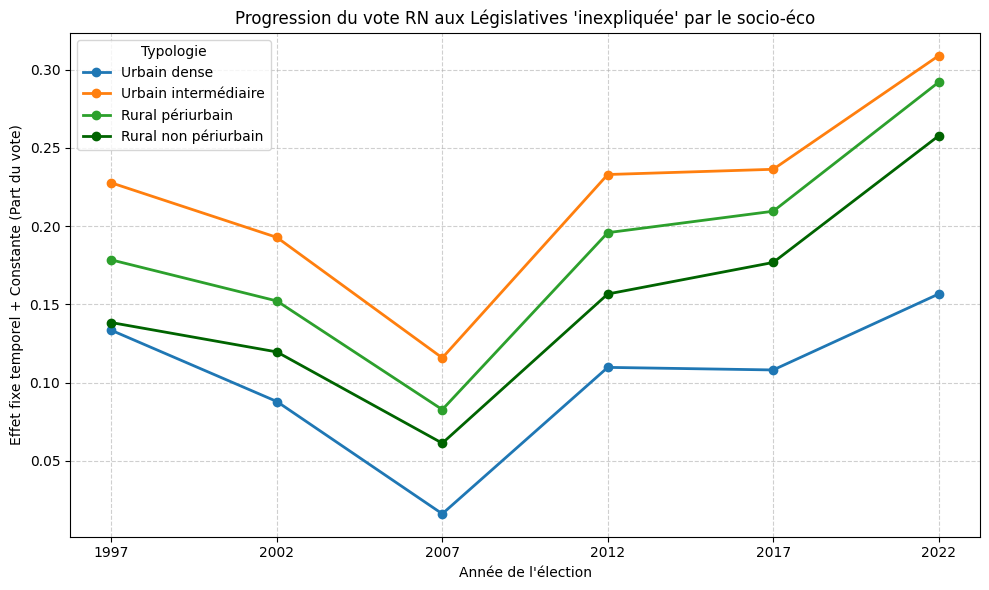

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

# 1. Nettoyage de base (ATTENTION : on cible bien vote_RN_leg ici !)
df_clean = data.dropna(subset=['vote_RN_leg', 'typologie_urbaine', 'Annee', 'codecommune']).copy()

# 2. Détection dynamique des années d'élection législative
# On récupère toutes les années dispo pour les législatives et on les trie
annees_dispo = sorted(df_clean['Annee'].unique())
annee_ref = annees_dispo[0]            # La plus ancienne devient l'année de référence (ex: 1993 ou 1997)
annees_estimees = annees_dispo[1:]     # Les autres seront nos dummies estimées

# Création des dummies d'années (sans l'année de ref)
for annee in annees_estimees:
    df_clean[f'annee_{annee}'] = (df_clean['Annee'] == annee).astype(int)

# On configure le Panel
df_panel = df_clean.set_index(['codecommune', 'Annee'])

# Les 4 catégories présentes dans ta base
typologies = ['Urbain dense', 'Urbain intermédiaire', 'Rural périurbain', 'Rural non périurbain']

# Dictionnaire pour stocker les résultats pour le graphique
resultats_graphique = {'Année': [annee_ref] + annees_estimees}

# 3. Boucle : Une régression par sous-groupe (typologie)
for typo in typologies:
    df_sub = df_panel[df_panel['typologie_urbaine'] == typo]
    
    # On fait tomber les NaN spécifiques aux contrôles sur ce sous-groupe
    df_sub_clean = df_sub.dropna(subset=['pbac', 'psup', 'revmoy', 'petranger', 'pchom', 'pouem', 'paind'])
    
    # Création dynamique de la partie "années" de la formule
    formule_annees = ' + '.join([f'annee_{a}' for a in annees_estimees])
    
    # Formule avec contrôles socio-économiques
    formule = f'vote_RN_leg ~ 1 + {formule_annees} + pbac + psup + revmoy + petranger + pchom + pouem + paind + EntityEffects'
    
    mod = PanelOLS.from_formula(formule, data=df_sub_clean, drop_absorbed=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    
    # Extraction pour le graphique
    base_ref = res.params['Intercept']
    
    trajectoire = [base_ref] # Premier point : l'année de référence
    for annee in annees_estimees:
        niveau_annee = base_ref + res.params[f'annee_{annee}']
        trajectoire.append(niveau_annee)
        
    # On sauvegarde la trajectoire pour cette typologie
    resultats_graphique[typo] = trajectoire

# 4. Dessin du graphique
df_plot = pd.DataFrame(resultats_graphique).set_index('Année')

fig, ax = plt.subplots(figsize=(10, 6))

couleurs = {
    'Urbain dense': '#1f77b4',          
    'Urbain intermédiaire': '#ff7f0e',  
    'Rural périurbain': '#2ca02c',      
    'Rural non périurbain': '#006400'   
}

# Tracé des lignes
for typo in typologies:
    ax.plot(df_plot.index, df_plot[typo], marker='o', label=typo, color=couleurs[typo], linewidth=2)

# Esthétique
ax.set_title("Progression du vote RN aux Législatives 'inexpliquée' par le socio-éco")
ax.set_ylabel("Effet fixe temporel + Constante (Part du vote)")
ax.set_xlabel("Année de l'élection")
ax.set_xticks(resultats_graphique['Année']) # S'adapte tout seul aux années des législatives !
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Typologie')

plt.tight_layout()
plt.show()

En ordonnées on a la part en % du vote RN qui n'est pas expliquée par les covariables socio-eco.